# 03 - Augmentation preview

Noor picks a suspicious leaf on the slope during the week and brings it home. It is photographed **at home on the weekend** with her daughter's budget Android phone. The augmentation simulates exactly that, and nothing else (no field backgrounds, no sun on the slope, no fog or dew).

| Group | What it simulates |
|---|---|
| Home background | table, printed cloth, concrete, packed-earth floor, paper, a palm holding the leaf |
| Picked leaf | mild curl / warp and slight dulling of a leaf that waited for the weekend |
| Home lighting | window or doorway side light, yard / doorstep, dim interior, warm lamp |
| Budget camera | sensor noise, JPEG compression, low effective resolution |
| Handheld | any rotation, off-centre framing, tip running out of frame, light motion blur / defocus |

All of it is **synthetic** and will be labelled as such in the data card.

**Label-safety caps**: hue shifts stay within a few degrees (no yellowing or browning, which would look like rust or leaf spot), no blotches are drawn, and blur / downscale / JPEG strength is capped so small lesions stay visible at the 256 px model input.

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import time
from collections import Counter

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import augment as aug
from src.backgrounds import KINDS, generate
from src.config import CLASSES, CROPS, MASKS, SPLITS

ARTIFACTS = ML / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110})

def load_leaf(image_id):
    crop = cv2.cvtColor(cv2.imread(str(CROPS / f"{image_id}.jpg")), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(MASKS / f"{image_id}.png"), cv2.IMREAD_GRAYSCALE)
    return crop, mask

def show_row(images, titles, suptitle=None, size=2.6):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size + 0.4))
    for ax, im, t in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(im)
        ax.set_title(t, fontsize=8)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=10)
    plt.tight_layout()

train = pd.read_csv(SPLITS / "train.csv")
DEMO_ID = 1348  # rust: several small yellow-orange spots, a good test for colour and blur caps
crop, mask = load_leaf(DEMO_ID)
base = aug.eval_view(crop, mask, size=aug.CANVAS)

## Home backgrounds (procedural)

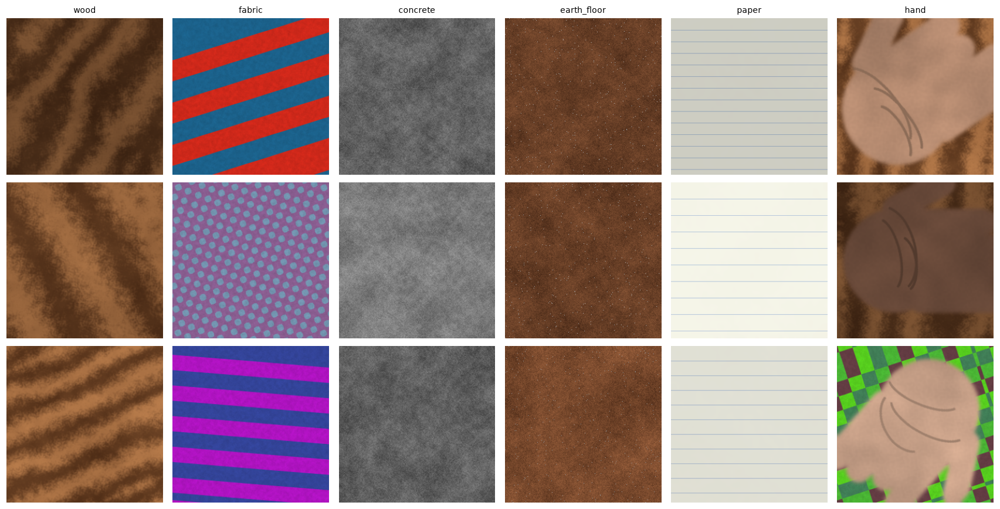

In [2]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(3, len(KINDS), figsize=(2.6 * len(KINDS), 8))
for c, kind in enumerate(KINDS):
    for r in range(3):
        axes[r, c].imshow(generate(kind, 256, 256, rng))
        axes[r, c].axis("off")
    axes[0, c].set_title(kind, fontsize=9)
plt.tight_layout()

## The same leaf, one augmentation group at a time

### Geometry and background
`eval view` is what validation and test images look like: centred, unrotated, on BRACOL-style white paper.

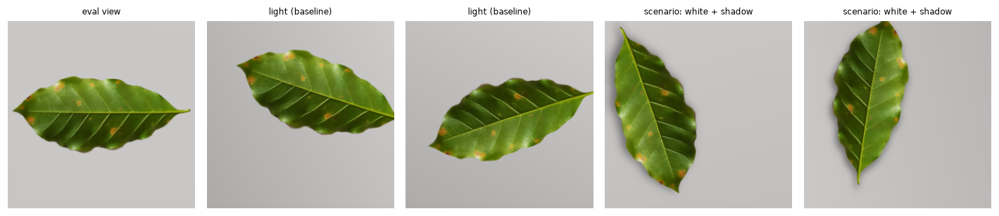

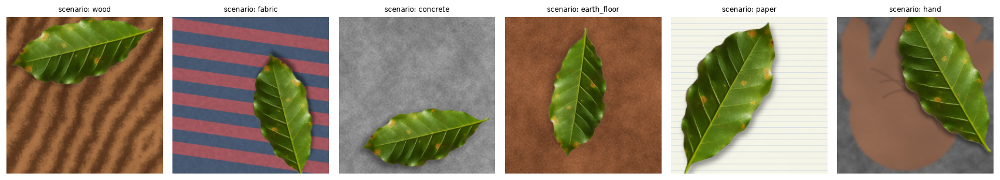

In [3]:
rng = np.random.default_rng(1)
imgs = [aug.eval_view(crop, mask), aug.light(crop, mask, rng), aug.light(crop, mask, rng)]
titles = ["eval view", "light (baseline)", "light (baseline)"]
for _ in range(2):
    imgs.append(aug.to_model_size(aug.place_leaf(crop, mask, rng, background="white")[0]))
    titles.append("scenario: white + shadow")
show_row(imgs, titles)

show_row([aug.to_model_size(aug.place_leaf(crop, mask, rng, background=k)[0]) for k in KINDS],
         [f"scenario: {k}" for k in KINDS])

### Picked leaf (curl and dulling)

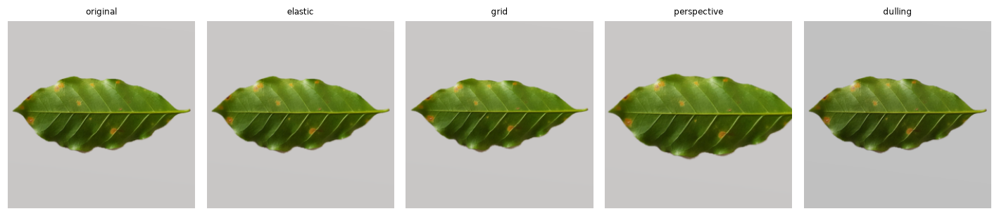

In [4]:
rng = np.random.default_rng(2)
imgs = [aug.to_model_size(base)] + [aug.to_model_size(aug.apply(t, base, rng)) for t in aug.CURL_VARIANTS.values()]
imgs.append(aug.to_model_size(aug.apply(aug._DULL, base, rng)))
show_row(imgs, ["original"] + list(aug.CURL_VARIANTS) + ["dulling"])

### Home lighting

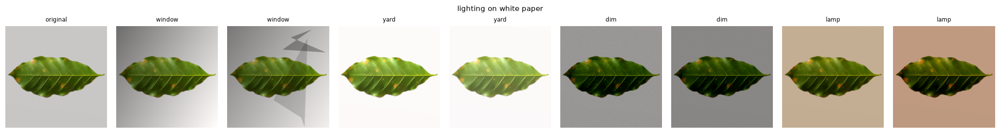

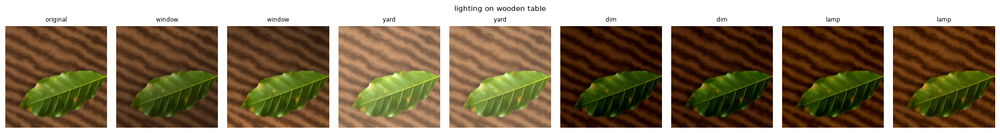

In [5]:
rng = np.random.default_rng(3)
home = aug.place_leaf(crop, mask, np.random.default_rng(7), background="wood", angle=20)[0]
for start, name in [(base, "white paper"), (home, "wooden table")]:
    imgs, titles = [aug.to_model_size(start)], ["original"]
    for kind in aug.LIGHTING:
        for _ in range(2):
            imgs.append(aug.to_model_size(aug.home_lighting(start, rng, kind=kind)))
            titles.append(kind)
    show_row(imgs, titles, suptitle=f"lighting on {name}", size=2.1)

### Budget camera and handheld blur (applied at the 256 px model input)

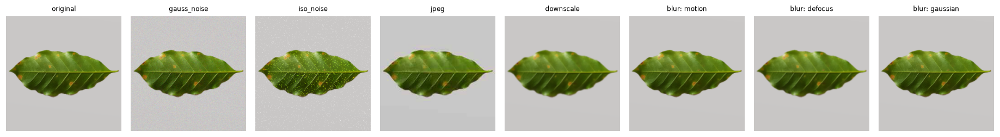

In [6]:
rng = np.random.default_rng(4)
small = aug.to_model_size(base)
variants = {**aug.CAMERA_VARIANTS, **{f"blur: {k}": v for k, v in aug.BLUR_VARIANTS.items()}}
show_row([small] + [aug.apply(t, small, rng) for t in variants.values()], ["original"] + list(variants), size=2.1)

## Label safety: do small lesions survive the strongest settings?

Each camera and blur transform at the top of its allowed range, plus the worst combination the pipeline can produce (downscale, then JPEG, then blur), on a cercospora leaf with small spots. The bottom row zooms into the same region of each image.

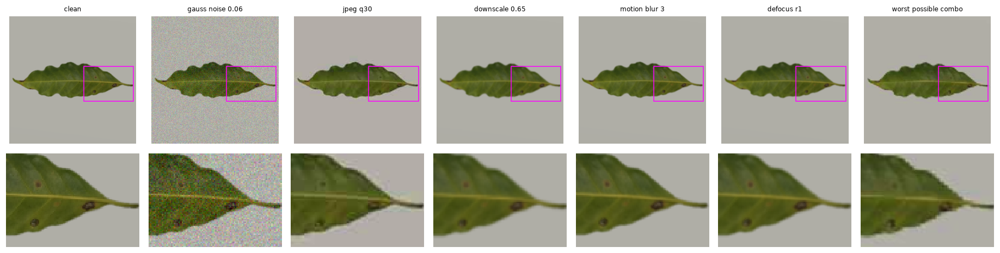

In [7]:
c_crop, c_mask = load_leaf(1582)
clean = aug.eval_view(c_crop, c_mask)
worst = {
    "gauss noise 0.06": A.GaussNoise(std_range=(0.06, 0.06), p=1),
    "jpeg q30": A.ImageCompression(quality_range=(30, 30), p=1),
    "downscale 0.65": A.Downscale(scale_range=(0.65, 0.65), interpolation_pair={"downscale": cv2.INTER_AREA, "upscale": cv2.INTER_LINEAR}, p=1),
    "motion blur 3": A.MotionBlur(blur_limit=(3, 3), p=1),
    "defocus r1": A.Defocus(radius=(1, 1), alias_blur=(0.2, 0.2), p=1),
    "worst possible combo": A.Compose([A.Downscale(scale_range=(0.65, 0.65), p=1), A.ImageCompression(quality_range=(50, 50), p=1),
                                       A.MotionBlur(blur_limit=(3, 3), p=1)]),
}
rng = np.random.default_rng(5)
imgs = [clean] + [aug.apply(t, clean, rng) for t in worst.values()]
titles = ["clean"] + list(worst)

y0, y1, x0, x1 = 100, 170, 150, 250
fig, axes = plt.subplots(2, len(imgs), figsize=(2.4 * len(imgs), 4.6))
for k, (im, t) in enumerate(zip(imgs, titles)):
    axes[0, k].imshow(im)
    axes[0, k].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="magenta", lw=1))
    axes[0, k].set_title(t, fontsize=8)
    axes[1, k].imshow(im[y0:y1, x0:x1], interpolation="nearest")
    for ax in axes[:, k]:
        ax.axis("off")
plt.tight_layout()

## Full scenario pipeline: 8 random training samples per class

This is what the model will actually train on. Titles list the steps that fired. Saved to `ml/artifacts/aug_preview.png`.

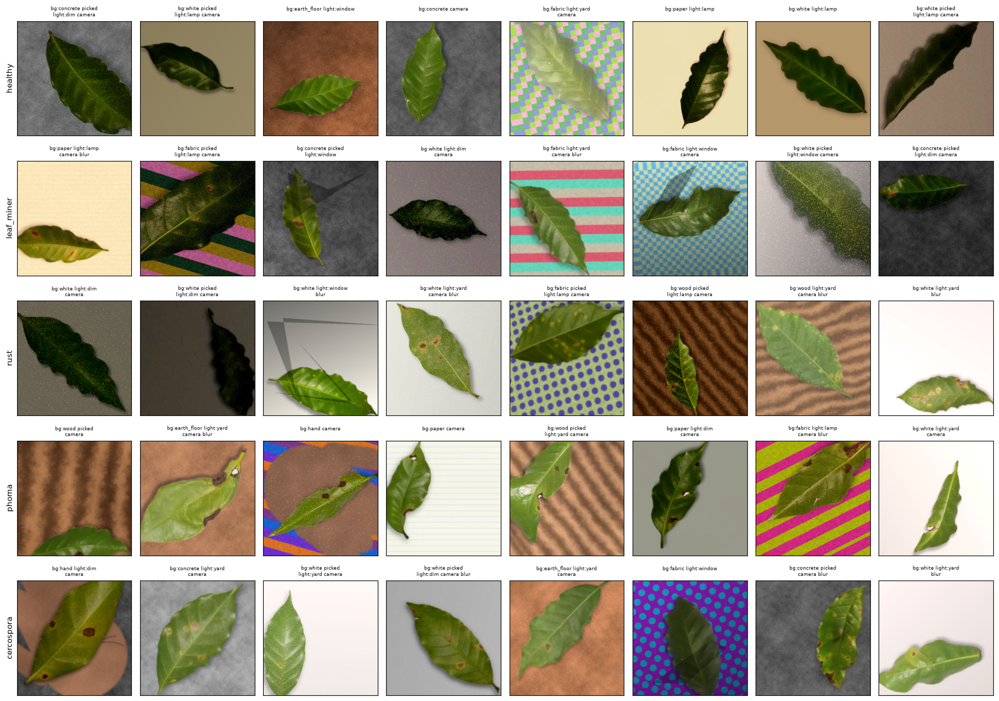

In [8]:
rng = np.random.default_rng(6)
n = 8
fig, axes = plt.subplots(len(CLASSES), n, figsize=(2.2 * n, 2.5 * len(CLASSES)))
for r, name in enumerate(CLASSES):
    ids = train[train["label"] == r]["id"].sample(n, random_state=r).tolist()
    for c, image_id in enumerate(ids):
        im, steps = aug.scenario(*load_leaf(image_id), rng, return_steps=True)
        ax = axes[r, c]
        ax.imshow(im)
        ax.set_title("\n".join([" ".join(steps[:2]), " ".join(steps[2:])]), fontsize=6)
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(name, fontsize=10)
plt.tight_layout()
fig.savefig(ARTIFACTS / "aug_preview.png", dpi=110, bbox_inches="tight")

## Baseline (light) pipeline for comparison

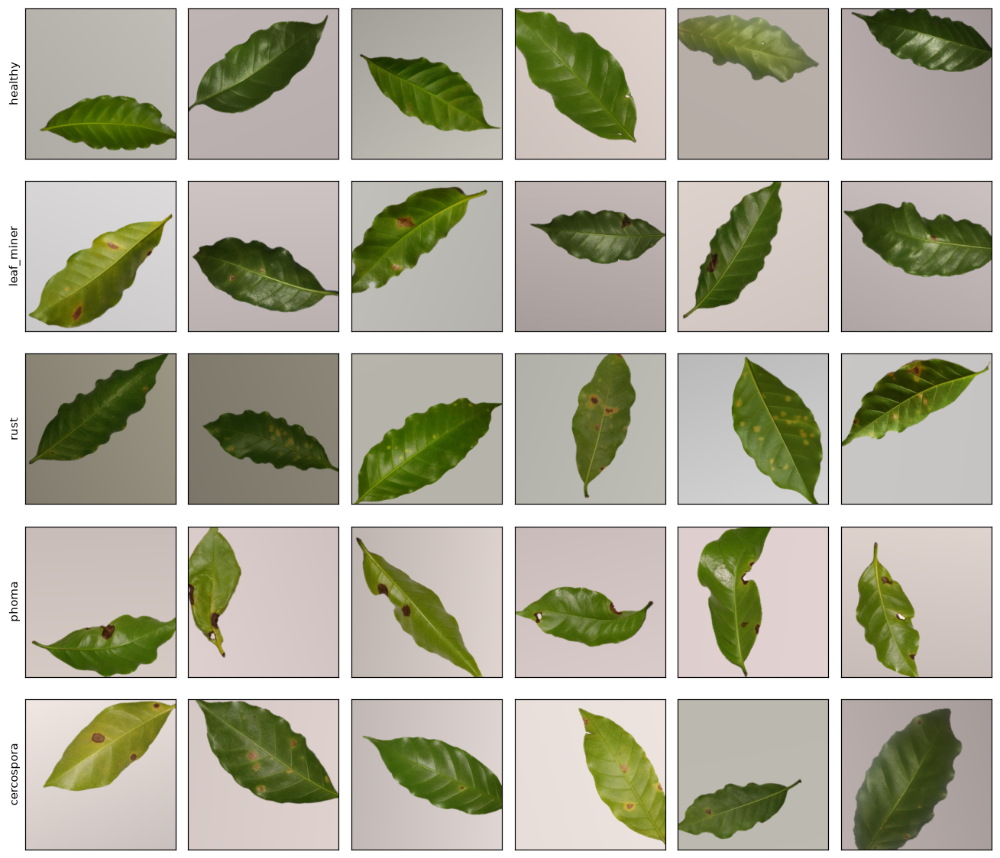

In [9]:
rng = np.random.default_rng(8)
n = 6
fig, axes = plt.subplots(len(CLASSES), n, figsize=(2 * n, 2.1 * len(CLASSES)))
for r, name in enumerate(CLASSES):
    ids = train[train["label"] == r]["id"].sample(n, random_state=r).tolist()
    for c, image_id in enumerate(ids):
        axes[r, c].imshow(aug.light(*load_leaf(image_id), rng))
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if c == 0:
            axes[r, c].set_ylabel(name, fontsize=10)
plt.tight_layout()

## How often each step fires, and speed

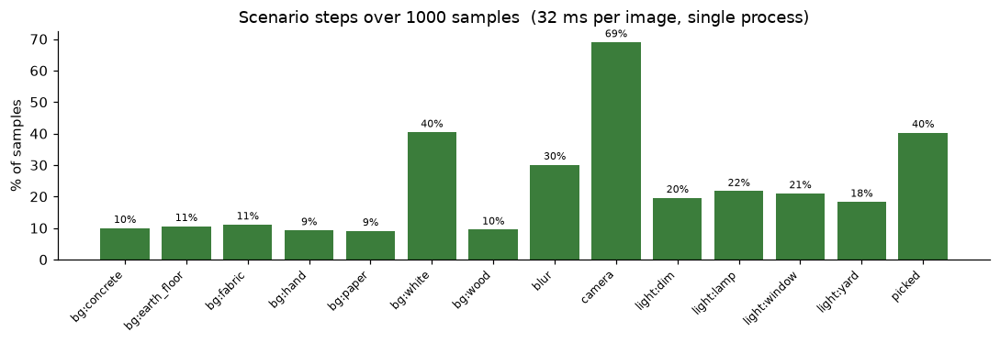

In [10]:
rng = np.random.default_rng(9)
leaves = [load_leaf(i) for i in train["id"].sample(50, random_state=0)]
counts, N = Counter(), 1000
t = time.time()
for k in range(N):
    _, steps = aug.scenario(*leaves[k % len(leaves)], rng, return_steps=True)
    counts.update(steps)
ms = (time.time() - t) / N * 1000

freq = pd.Series(counts).sort_index() / N * 100
fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(freq.index, freq.values, color="#3b7d3b")
ax.bar_label(bars, fmt="%.0f%%", fontsize=7, padding=2)
ax.set_ylabel("% of samples")
ax.set_title(f"Scenario steps over {N} samples  ({ms:.0f} ms per image, single process)")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()